## We present result on natural images including 

1.horizontal connection visualualization

2.denoising result of natural images, compare to sparse coding

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

from recurrent_diffusion_pkg.utils import (
    load_lit_model,
    fit_decoder_level_gabor_bank,
    plot_gabor_needles,
    plot_original_vs_reconstructed_gabor,
    build_loaders_from_config,
    vis_patches
)
# natural scene model
# BASE_DIR = Path("/home/zeyuy/recurrent_diffusion_minimal/pretrained_model/scaling-VH-new-2/00005_simple_sheet7_simple_control_small_noise")
# larger face model
BASE_DIR = Path("pretrained_model/scaling-new-face/00026_simplify_layer1_neural_sheet7_intra_film_scalar_mul_ff_scale_large_large_noise_simple_control")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

config, lit_model = load_lit_model(BASE_DIR, device=DEVICE, ckpt_name=None)
net = lit_model.ema_model.eval()

print("Loaded:", BASE_DIR)
print("n_levels:", net.n_levels)

<class 'recurrent_diffusion_pkg.model.neural_sheet7'>
EMA <class 'recurrent_diffusion_pkg.model.neural_sheet7'>
Loaded: pretrained_model/scaling-new-face/00026_simplify_layer1_neural_sheet7_intra_film_scalar_mul_ff_scale_large_large_noise_simple_control
n_levels: 4


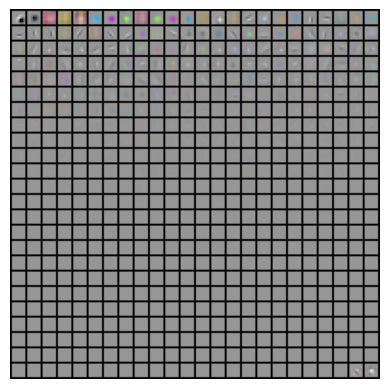

In [9]:
# visualize all the ff neurons
# visualize neurons all
w_v_all_ls = []
w_g_all_ls = []
for level in range(net.n_levels):
    net.levels[level].reset_wnorm()
    w_v = net.levels[level].encoder_node.encoder.weight.data.detach()
    w_g = net.levels[level].encoder_node.encoder.weight_g.data.flatten().detach()
    w_v_all_ls.append(w_v)
    w_g_all_ls.append(w_g)
w_v_all = torch.cat(w_v_all_ls)
w_g_all = torch.cat(w_g_all_ls)

w_g_all_sort_v,w_g_all_sort_idx = w_g_all.sort(descending=True)
vis_patches(w_v_all[w_g_all_sort_idx].flatten(2).cpu(),name = 'ff_raw_weight_face')

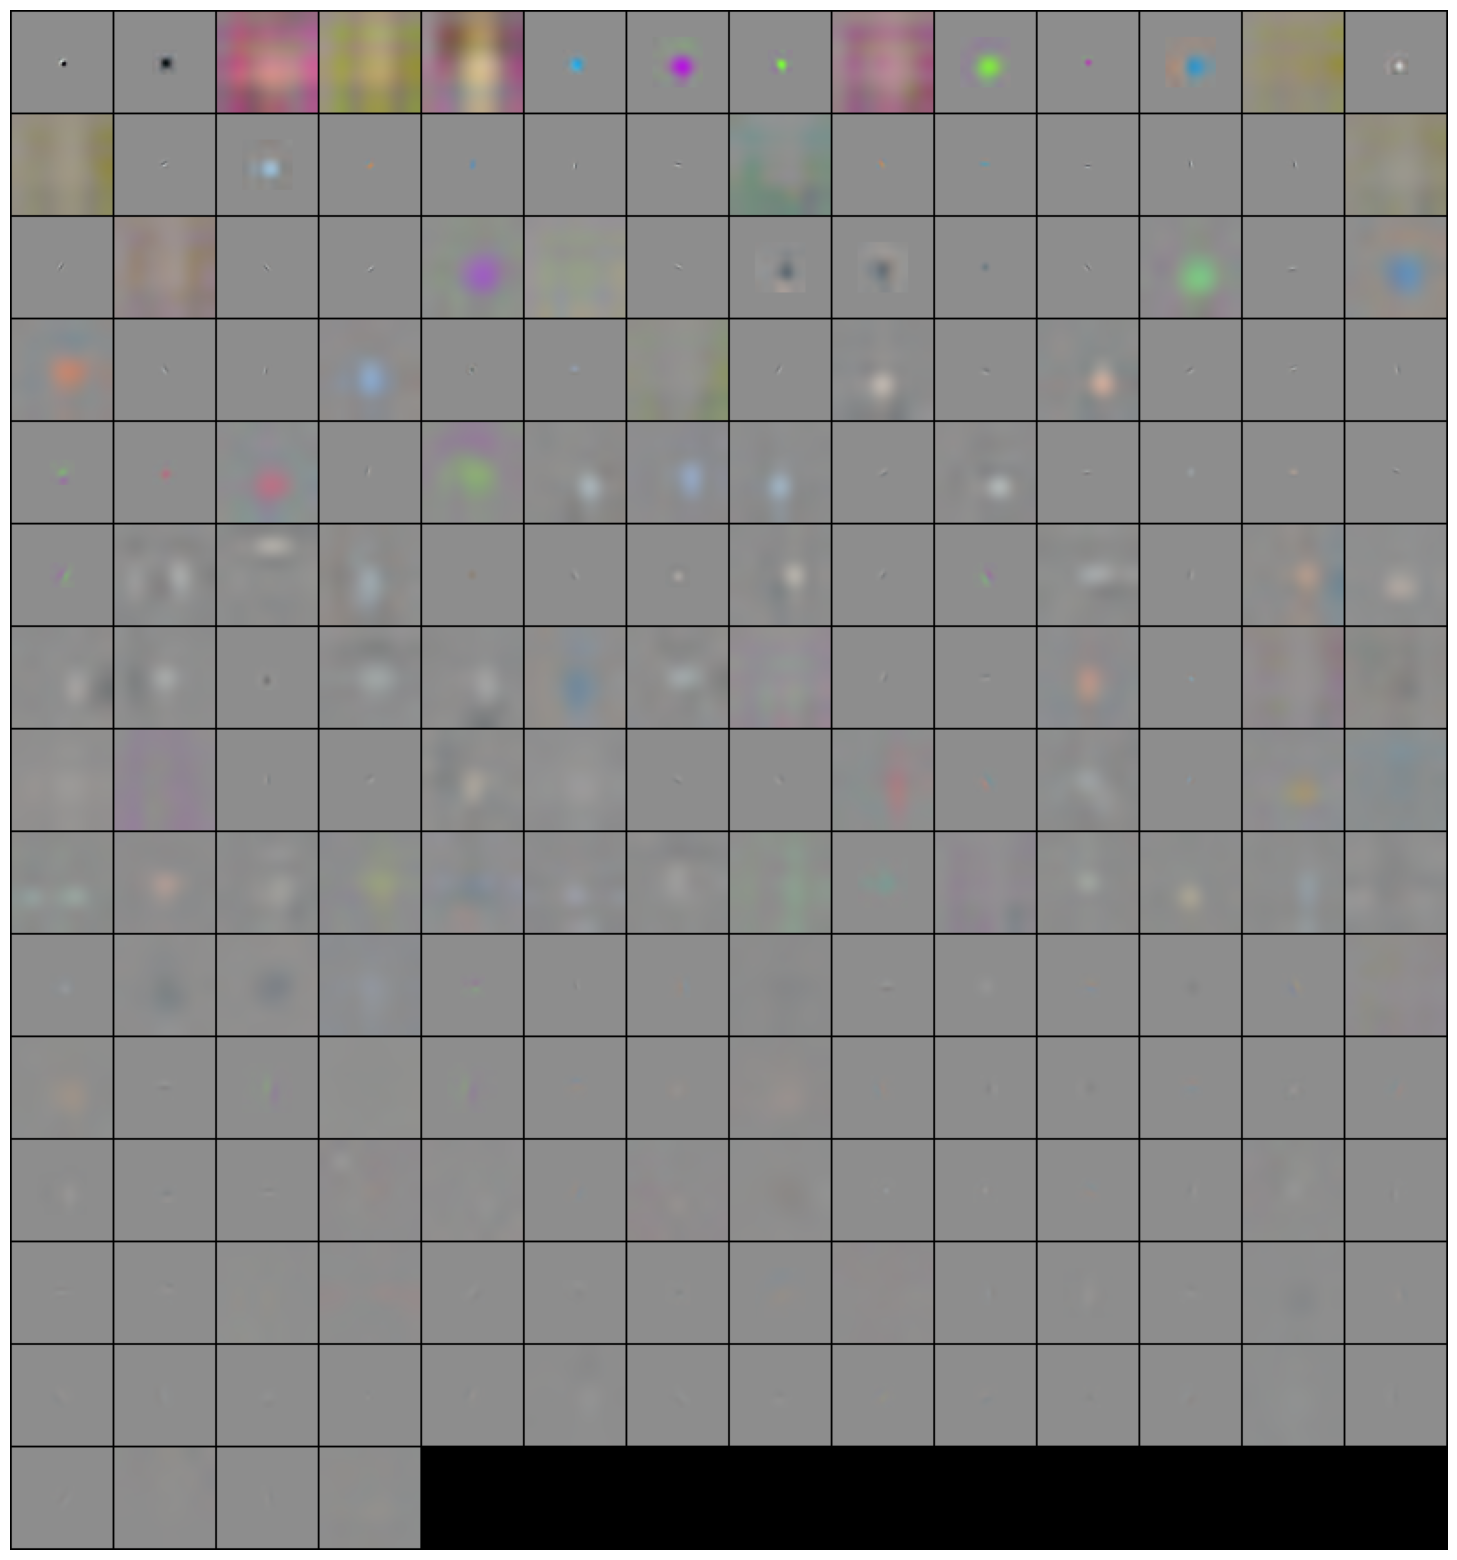

In [25]:


import torch
import torch.nn.functional as F

w_v_all_ls = []
w_g_all_ls = []

# Calculate the effective receptive field size of the highest level
base_kernel_size = 7
max_scale_factor = 2 ** (net.n_levels - 1)
target_size = base_kernel_size * max_scale_factor 

for level in range(net.n_levels):
    net.levels[level].reset_wnorm()
    
    w_v = net.levels[level].encoder_node.encoder.weight.data.detach()
    w_g = net.levels[level].encoder_node.encoder.weight_g.data.flatten().detach()
    
    level_scale = 2 ** level
    
    if level_scale > 1:
        w_v = F.interpolate(w_v, scale_factor=level_scale, mode='bicubic', align_corners=False)
        
    current_size = w_v.shape[-1]
    
    # --- CORRECTED PADDING LOGIC ---
    if current_size < target_size:
        pad_total = target_size - current_size
        pad_before = pad_total // 2
        pad_after = pad_total - pad_before
        
        # F.pad expects: (left, right, top, bottom)
        w_v = F.pad(w_v, (pad_before, pad_after, pad_before, pad_after), mode='constant', value=0)

    w_v_all_ls.append(w_v)
    w_g_all_ls.append(w_g)

# Now all filters are guaranteed to be exactly (target_size x target_size)
w_v_all = torch.cat(w_v_all_ls, dim=0)
w_g_all = torch.cat(w_g_all_ls, dim=0)

w_g_all_sort_v, w_g_all_sort_idx = w_g_all.sort(descending=True)
vis_patches(w_v_all[w_g_all_sort_idx][:200].flatten(2).cpu(),figsize = (20,20),name = 'ff_weight_face_top_200')

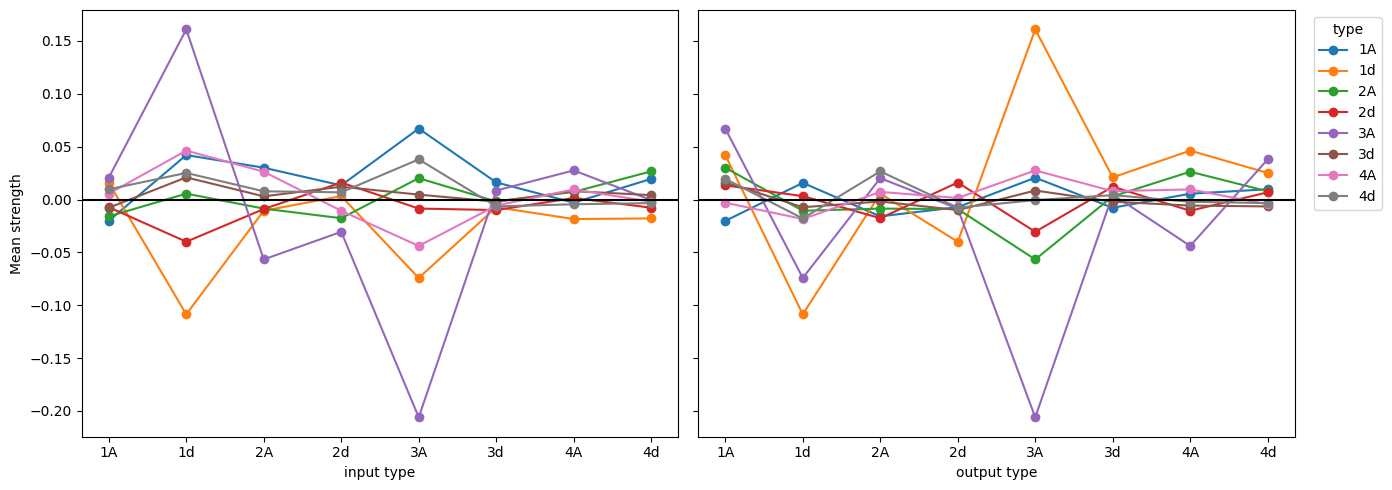

In [53]:
n_total_filters = len(w_g_all_sort_v)  

filters = []
attached = []
horizontal_connections = []
unit_levels = []   # level index for each unit, concatenated across levels
unit_attach = []   # attached/detached flag for each unit, concatenated across levels

for level in range(net.n_levels):
    net.levels[level].reset_wnorm()
    w_v = net.levels[level].encoder_node.encoder.weight.data.detach()
    w_g = net.levels[level].encoder_node.encoder.weight_g.data.flatten().detach()

    filters.append(w_v)

    is_attached = (w_g > 0.25)
    attached.append(is_attached)

    n_filters = len(w_g)

    # generate random horizontal connections
    hc = torch.randn(n_filters, n_total_filters)
    horizontal_connections.append(hc)

    unit_levels.extend([level] * n_filters)
    unit_attach.extend(is_attached.cpu().numpy().tolist())

unit_levels = np.array(unit_levels)
unit_attach = np.array(unit_attach, dtype=bool)


# Build class labels
class_labels = []
class_masks = {}

for level in range(net.n_levels):
    for is_attached, suffix in [(True, "A"), (False, "d")]:
        label = f"{level + 1}{suffix}"
        mask = (unit_levels == level) & (unit_attach == is_attached)
        class_labels.append(label)
        class_masks[label] = mask

n_classes = len(class_labels)


# assemble full horizontal weight matrix
W = torch.cat(horizontal_connections, dim=0).detach().cpu().numpy()

avg_out = np.full((n_classes, n_classes), np.nan)
avg_in = np.full((n_classes, n_classes), np.nan)

for i, src_label in enumerate(class_labels):
    src_idx = np.where(class_masks[src_label])[0]

    for j, tgt_label in enumerate(class_labels):
        tgt_idx = np.where(class_masks[tgt_label])[0]

        if len(src_idx) == 0 or len(tgt_idx) == 0:
            continue

        block = W[np.ix_(src_idx, tgt_idx)]   # src -> tgt
        avg_out[i, j] = block.mean()

        block_in = W[np.ix_(tgt_idx, src_idx)]  # tgt receives from src
        avg_in[i, j] = block_in.mean()


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

x = np.arange(n_classes)

# incoming subplot
for i, tgt_label in enumerate(class_labels):
    axes[0].plot(x, avg_in[i], marker='o', label=tgt_label)
axes[0].set_xlabel("input type")
axes[0].set_ylabel("Mean strength")
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_labels, rotation=0)
axes[0].axhline(0, c="k")

# outgoing subplot
for i, src_label in enumerate(class_labels):
    axes[1].plot(x, avg_out[i], marker='o', label=src_label)
axes[1].set_xlabel("output type")
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_labels, rotation=0)
axes[1].axhline(0,c="k")

axes[1].legend(title="type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()